# Public investment and nearby business engagement
### Five local projects · Exploratory Data Analysis
**CIS 509 — Course Project Milestone 2 · Team 4 · September 12, 2026**  
John Wheeler (`jwheele4`) · Ryan Wolff (`rwwolff`) · Cameron Anthony (`cantho19`)

> **Main finding:** Some projects are associated with more nearby business engagement, but customer experience does not improve consistently. Results vary by project, income context, business population and geographic scope. These observations do not establish causation.

## 1. Project overview
Public investments can improve access, public space and opportunities for local businesses. Economic-development teams need to understand whether those changes are reflected in business activity and customer experience—and whether patterns differ across communities.

**Research question:** How do recorded business engagement and review experience change near five funded projects, relative to farther businesses, and how do the patterns vary by baseline local income, project type and reported cost?

We explore three expectations: **(H1)** nearby engagement grows faster; **(H2)** stars and review sentiment improve; and **(H3)** patterns differ by neighborhood income and project characteristics. These are exploratory questions developed during the project, not pre-registered confirmatory tests. We retain unfavorable results and insufficient-sample cases.

Yelp reviews, distinct reviewers, check-ins and tips are **engagement proxies**. They do not directly measure resident participation, verified visits, revenue or community welfare. Higher engagement can be useful without implying that every business or resident benefits.


## 2. Data sources and study design
Five cases were chosen for a documented local footprint, a usable opening date, Yelp coverage and full pre/post years. The three additions were selected before their outcomes were calculated. The sample is purposive; it is not representative of all public investments.

| Project | Location and intervention | Reported cost and source |
|---|---|---|
| Lafitte Greenway | New Orleans · greenway/public space · opened November 2015 | **$9.1 m** — [project opening account](https://lafittegreenway.org/blog/lafitte-greenway-opening-friday-november-6/) |
| Sun Link | Tucson · streetcar · opened July 2014 | **$196.5 m** — [Federal Transit Administration](https://www.transit.dot.gov/about/news/us-department-transportation-celebrates-grand-opening-tucson-streetcar-further-expanding) |
| Dilworth Park | Philadelphia · civic plaza/transit access · opened September 2014 | **$55 m** — [Center City District](https://centercityphila.org/press-release/dilworth-park-celebrates-10th-anniversary/) |
| Water Works Park | Tampa · park/spring restoration · completed August 2014 | **$7.4 m** — [funding interviews](https://83degreesmedia.com/waterworks100813/), [city completion account](https://www.tampa.gov/sites/default/files/document/migrated/FY15BudgetBook_part1.pdf) |
| Riverfront Park / Ascend | Nashville · 2015 park addition/performance venue | **$52 m** — [contemporaneous site-tour report](https://www.nashvillescene.com/music/slideshow-take-a-look-inside-ascend-amphitheater/article_f535a107-e8bc-5138-b3aa-3afb4f7e2ae0.html), [Metro annual report](https://www.nashville.gov/sites/default/files/2021-04/2016AnnualReport-Final_v6_web.pdf) |

These are **nominal reported total project costs**, not a reconciled series of actual public expenditures. Dilworth combines public/private funding, and its headline cost differs in scope from the [CCD capital ledger](https://files.centercityphila.org/pdf/SOCC2016.pdf). Costs provide context; five largely distinct project/city combinations cannot identify a cost or project-type effect.

| Data source | Records used and collection |
|---|---|
| [Yelp Open Dataset](https://www.yelp.com/dataset) | Local raw archive: business coordinates/categories, dated reviews with stars/text, opaque reviewer IDs, check-in timestamps and dated tips. Businesses within 8 km of each footprint; project-specific complete years within 2008–2019 (Lafitte starts 2010). All business categories and snapshot open/closed statuses retained. |
| [Census ACS five-year estimates](https://www.census.gov/programs-surveys/acs/data/summary-file.html) | Official downloaded summary files: ZIP/ZCTA median household income and poverty. ACS 2011 for Sun Link/Dilworth; ACS 2012 for the others, ending within baseline and before construction. Published uncertainty is retained in the underlying Census extracts. |
| Public GIS and mapped footprints | [Tucson GIS](https://gis.tucsonaz.gov/arcgis/rest/services/PublicMaps/OpenData_Transportation/MapServer/10), [Nashville GIS](https://services2.arcgis.com/HdTo6HJqh92wn4D8/arcgis/rest/services/Park_Boundary_View/FeatureServer/6), current OSM [Dilworth](https://www.openstreetmap.org/way/410095875), [Water Works](https://www.openstreetmap.org/way/190127200), and named Lafitte trail segments. Metric distances use local UTM projections. |
| Project accounts above | Opening dates, construction gaps, intervention type and reported funding/cost scope. These are separate from the broad federal-assistance transactions explored earlier in the project. |


In [1]:
"""Publication-style figures for the five-project EDA; only aggregate inputs are used."""
from pathlib import Path
import textwrap,json
import numpy as np,pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch,Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
ORDER=['Lafitte','Sun Link','Dilworth Park','Water Works Park','Riverfront / Ascend']
NAMES=['Lafitte Greenway','Sun Link','Dilworth Park','Water Works Park','Riverfront / Ascend']
INK='#20334A';TEAL='#187D8D';ORANGE='#BD623C';GOLD='#D6A744';GRAY='#95A1AC';PALE='#E9EDF0'
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'figure.dpi':140,'savefig.dpi':180,'axes.spines.top':False,'axes.spines.right':False,'axes.spines.left':False,'axes.edgecolor':'#B8C0C8','axes.labelcolor':INK,'text.color':INK,'xtick.color':INK,'ytick.color':INK,'axes.titleweight':'bold','axes.titlesize':11,'figure.facecolor':'white','axes.facecolor':'white'})
def finish(fig,out,name):
 out=Path(out);out.mkdir(exist_ok=True);fig.savefig(out/(name+'.png'),bbox_inches='tight',facecolor='white');fig.savefig(out/(name+'.svg'),bbox_inches='tight',facecolor='white');return fig
def title(fig,headline,subtitle):
 fig.suptitle(headline,x=.02,y=.99,ha='left',fontsize=18,fontweight='bold');fig.text(.02,.90,subtitle,fontsize=10,color='#596876',va='top')
def study_design(reg,out):
 fig,ax=plt.subplots(figsize=(12.7,5.2));fig.subplots_adjust(left=.21,right=.82,top=.78,bottom=.17)
 types=['Greenway / public space','Streetcar / transit','Civic plaza / transit access','Park / spring restoration','Park / performance venue']
 for i,p in enumerate(ORDER):
  r=reg.set_index('project').loc[p];pre=r['pre'];post=r['post'];opening=pd.Timestamp(r.opening);year=opening.year+(opening.dayofyear-1)/365.25
  ax.broken_barh([(pre[0],2)],(i-.14,.28),facecolors=GRAY);ax.broken_barh([(max(pre)+1,min(post)-max(pre)-1)],(i-.14,.28),facecolors=PALE);ax.broken_barh([(post[0],2)],(i-.14,.28),facecolors=TEAL)
  ax.scatter(year,i,marker='D',s=35,color=GOLD,zorder=3);ax.text(2018.38,i-.07,f'${r.cost_millions:g}m',fontsize=12,fontweight='bold',va='center');ax.text(2018.38,i+.18,types[i],fontsize=8.5,va='center',color='#596876')
 ax.set(yticks=range(5),yticklabels=[f'{NAMES[i]}\n{reg.set_index("project").loc[p,"city"]}' for i,p in enumerate(ORDER)],xlim=(2009.8,2018.1),ylim=(4.6,-.6),xticks=range(2010,2019),xlabel='Calendar year');ax.grid(axis='x',color=PALE);ax.set_axisbelow(True);ax.tick_params(axis='y',length=0,pad=12)
 title(fig,'Five funded projects, five local settings','Equal two-year baseline and follow-up windows; construction/opening gaps excluded.')
 fig.text(.835,.825,'REPORTED COST / TYPE',fontsize=9,fontweight='bold')
 fig.legend(handles=[Patch(color=GRAY,label='Before construction'),Patch(color=PALE,label='Excluded gap'),Line2D([],[],marker='D',linestyle='',color=GOLD,label='Opening'),Patch(color=TEAL,label='Post-opening')],loc='lower center',ncol=4,frameon=False,bbox_to_anchor=(.47,.01),fontsize=9)
 return finish(fig,out,'01_study_design')
def coverage(overview,quality,support,out):
 z=overview.set_index('project').loc[ORDER].join(quality.set_index('project')[['baseline_near_500']]).join(support.query("radius_m==500 and income_group=='All'").set_index('project')[['matched_pairs']]);fig,ax=plt.subplots(figsize=(12,4.7));fig.subplots_adjust(left=.20,right=.78,top=.77,bottom=.15)
 y=np.arange(5);ax.barh(y,100,color=PALE,height=.6);ax.barh(y,100*z.baseline_near_500/z.listed_500m,color=GOLD,height=.6);ax.barh(y,100*z.matched_pairs/z.listed_500m,color=TEAL,height=.6)
 for i,p in enumerate(ORDER):ax.text(103,i,f'{int(z.loc[p,"matched_pairs"]):,} / {int(z.loc[p,"listed_500m"]):,}',va='center',fontsize=11,fontweight='bold',color=ORANGE if p=='Water Works Park' else INK)
 ax.set(yticks=y,yticklabels=NAMES,xlim=(0,100),ylim=(4.6,-.6),xticks=[0,25,50,75,100],xlabel='Share of nearby listings (%)');ax.tick_params(axis='y',length=0);title(fig,'Coverage limits the strength of the comparison','Four cases support a primary matched comparison; Water Works has only two matched businesses.')
 fig.text(.80,.81,'MATCHED / LISTED',fontsize=9,fontweight='bold');fig.legend(handles=[Patch(color=TEAL,label='Matched'),Patch(color=GOLD,label='Baseline ≥5, unmatched'),Patch(color=PALE,label='Fewer than 5 baseline reviews')],loc='lower center',ncol=3,frameon=False,bbox_to_anchor=(.52,-.02),fontsize=9)
 return finish(fig,out,'02_coverage')
def text_diagnostics(cm,length,out):
 fig,axes=plt.subplots(1,2,figsize=(12.8,5.1),gridspec_kw={'width_ratios':[1,1.3]});fig.subplots_adjust(left=.09,right=.96,bottom=.19,top=.75,wspace=.65)
 z=cm.groupby(['stars','vader_label']).reviews.sum().unstack(fill_value=0).reindex(index=[1,2,3,4,5],columns=['Negative','Neutral','Positive']);pct=100*z.div(z.sum(axis=1),axis=0);ax=axes[0];ax.imshow(pct,cmap='Blues',vmin=0,vmax=100,aspect='auto')
 for i in range(5):
  for j in range(3):ax.text(j,i,f'{pct.iloc[i,j]:.1f}%',ha='center',va='center',color='white' if pct.iloc[i,j]>60 else INK,fontweight='bold')
 ax.set(xticks=range(3),xticklabels=pct.columns,yticks=range(5),yticklabels=[f'{i} star'+('' if i==1 else 's') for i in range(1,6)],title='VADER labels within each star rating',xlabel='Whole-review sentiment label');ax.tick_params(length=0)
 ax=axes[1];z=length.set_index('project').loc[ORDER];y=np.arange(5);ax.hlines(y,z.p10_words,z.p90_words,color=GRAY,lw=3);ax.scatter(z.median_words,y,color=TEAL,s=50,zorder=3)
 for i,row in enumerate(z.itertuples()):ax.text(row.p90_words+7,i,str(int(row.median_words))+' median',va='center',fontsize=9)
 ax.set(yticks=y,yticklabels=NAMES,ylim=(4.5,-.5),xlim=(0,340),title='Review length varies substantially',xlabel='Words per review');ax.tick_params(axis='y',length=0);ax.grid(axis='x',color=PALE)
 title(fig,'Positive language can appear in low-star reviews','Full pre/post review text within 500 m: stars are a weak validation label, not human sentiment ground truth.')
 fig.text(.57,.04,'Line: 10th–90th percentile   •   Dot: median',fontsize=9,color='#596876')
 return finish(fig,out,'03_text_diagnostics')
def outcome_panel(activity,experience,out):
 fig,axes=plt.subplots(1,5,figsize=(15.3,5.2));fig.subplots_adjust(left=.16,right=.985,top=.73,bottom=.16,wspace=.25)
 specs=[('reviews','Review activity','Relative growth (%)',(-55,165)),('checkins','Check-ins','Relative growth (%)',(-55,190)),('tips','Tips','Relative growth (%)',(-60,180)),('stars','Stars','Change contrast (stars)',(-.13,.08)),('compound','VADER','Change contrast (compound)',(-.075,.06))]
 for ax,(metric,heading,xlabel,limits) in zip(axes,specs):
  z=activity.query("radius_m==500 and income_group=='All' and window=='Main'") if metric in ['reviews','checkins','tips'] else experience.query("radius_m==500 and income_group=='All'");z=z[z.metric.eq(metric)].set_index('project').reindex(ORDER);vcol='relative_growth_pct' if metric in ['reviews','checkins','tips'] else 'contrast'
  for i,p in enumerate(ORDER):
   val=z.at[p,vcol];n=z.at[p,'pairs']
   if n<20:ax.axhspan(i-.35,i+.35,color='#F3F4F5');ax.text(sum(limits)/2,i,'Sparse: n=2',ha='center',va='center',fontsize=8,color='#77828C');continue
   color=TEAL if val>=0 else ORANGE;ax.hlines(i,0,val,color=color,lw=2);ax.scatter(val,i,s=48,color=color,zorder=3);label=f'{val:+.1f}' if metric in ['reviews','checkins','tips'] else f'{val:+.3f}';ax.annotate(label,(val,i),xytext=(5 if val>=0 else -5,0),textcoords='offset points',ha='left' if val>=0 else 'right',va='center',fontsize=8)
  ax.axvline(0,color='#9AA5AF',lw=.8);ax.set(xlim=limits,ylim=(4.6,-.6),yticks=range(5),yticklabels=NAMES if ax==axes[0] else [],title=heading,xlabel=xlabel);ax.tick_params(axis='y',length=0);ax.tick_params(axis='x',labelsize=8);ax.xaxis.set_major_locator(plt.MaxNLocator(3));ax.grid(axis='y',color=PALE,zorder=0)
 title(fig,'Activity gains do not consistently translate into better ratings','Matched businesses within 500 m versus farther controls. Positive values favor nearby businesses; these are descriptive estimates.')
 fig.text(.16,.025,'Activity cohorts: 142 / 149 / 498 / 2 / 85 pairs.   Experience cohorts: 59 / 75 / 248 / 2 / 45 pairs, in project order.',fontsize=9,color='#596876')
 return finish(fig,out,'04_outcomes')
def income_panel(activity,support,out):
 fig,ax=plt.subplots(figsize=(11,5));fig.subplots_adjust(left=.24,right=.9,top=.75,bottom=.15);groups=['Lower','Middle','Higher'];z=activity.query("radius_m==500 and metric=='reviews' and window=='Main' and income_group!='All'").pivot(index='project',columns='income_group',values='relative_growth_pct').reindex(index=ORDER,columns=groups);n=support.query("radius_m==500 and income_group!='All'").pivot(index='project',columns='income_group',values='matched_pairs').reindex(index=ORDER,columns=groups);masked=z.mask(n<20)
 im=ax.imshow(masked,cmap='BrBG',norm=TwoSlopeNorm(vmin=-200,vcenter=0,vmax=200),aspect='auto')
 for i in range(5):
  for j in range(3):
   count=int(n.iloc[i,j]);value=z.iloc[i,j]
   if count<20:ax.add_patch(Rectangle((j-.5,i-.5),1,1,facecolor='#EEF0F2',edgecolor='white'));text='No pairs' if count==0 else f'Sparse\nn={count}';color='#78838E'
   else:text=f'{value:+.1f}%\nn={count}';color='white' if abs(value)>130 else INK
   ax.text(j,i,text,ha='center',va='center',color=color,fontsize=10)
 ax.set(xticks=range(3),xticklabels=['Lower local ZIP income','Middle local ZIP income','Higher local ZIP income'],yticks=range(5),yticklabels=NAMES);ax.tick_params(length=0);fig.colorbar(im,ax=ax,fraction=.045,pad=.025,label='Relative review growth (%)',ticks=[-200,-100,0,100,200]);title(fig,'Income patterns differ—and many groups are missing','Baseline ACS income at the business ZIP. City-relative thirds; not reviewer income or equal national income classes.')
 return finish(fig,out,'05_income')
def sensitivity(activity,influence,out):
 fig,axes=plt.subplots(1,5,figsize=(14,4.5),sharey=True);fig.subplots_adjust(left=.07,right=.98,top=.73,bottom=.18,wspace=.20)
 z=activity.query("income_group=='All' and metric=='reviews' and window=='Main'")
 for ax,p,name in zip(axes,ORDER,NAMES):
  q=z[z.project.eq(p)].sort_values('radius_m');q=q.copy();q.loc[q.pairs<20,'relative_growth_pct']=np.nan;ax.plot(q.radius_m,q.relative_growth_pct,color=GRAY,lw=1.8,marker='o',markersize=5)
  primary=q[q.radius_m.eq(500)]
  if primary.pairs.iloc[0]>=20:ax.scatter(500,primary.relative_growth_pct.iloc[0],color=TEAL,s=65,zorder=3)
  else:ax.text(.5,.8,'250 m / 500 m\nsamples too small',transform=ax.transAxes,ha='center',fontsize=9,color='#75828E')
  ax.axhline(0,color='#A7B0B8',lw=.8);ax.set(title=name,xticks=[250,500,1000],xlim=(175,1075),ylim=(-65,190),xlabel='Radius (m)');ax.tick_params(axis='x',labelsize=9);ax.grid(axis='y',color=PALE)
 axes[0].set_ylabel('Relative review growth (%)');title(fig,'The size of the association depends on geographic scope','Dots compare 250 m, 500 m and 1,000 m definitions; teal is the primary 500 m estimate. These are sensitivities, not confidence intervals.')
 return finish(fig,out,'06_sensitivity')
def topic_panel(topics,out):
 cats=['Food and dishes','Location/local identity (mixed)','Mixed evaluations/negation','Mixed interactions/intentions','Overall experience/service','Visit timing/waiting'];short=['Food /\ndishes','Local\nidentity\n(mixed)','Evaluation\n/ negation\n(mixed)','Interaction\n/ intention\n(mixed)','Experience\n/ service','Visit timing\n/ waiting']
 fig,axes=plt.subplots(1,2,figsize=(14,5.2));fig.subplots_adjust(left=.15,right=.98,top=.72,bottom=.23,wspace=.23)
 for ax,metric,heading,limit in zip(axes,['vader','stars'],['Category sentence sentiment','Associated whole-review stars'],[.10,.35]):
  z=topics[topics.area.eq('near')].pivot(index='project',columns=['period','category'],values=metric);delta=(z['post']-z['pre']).reindex(index=ORDER,columns=cats);im=ax.imshow(delta,cmap='BrBG',norm=TwoSlopeNorm(vmin=-limit,vcenter=0,vmax=limit),aspect='auto')
  for i in range(5):
   for j in range(6):
    v=delta.iloc[i,j]
    if pd.isna(v):ax.add_patch(Rectangle((j-.5,i-.5),1,1,facecolor='#EEF0F2',edgecolor='white'));label='—';color='#86909B'
    else:label=f'{v:+.2f}';color='white' if abs(v)>.65*limit else INK
    ax.text(j,i,label,ha='center',va='center',fontsize=8,color=color)
  ax.set(xticks=range(6),xticklabels=short,yticks=range(5),yticklabels=NAMES if ax==axes[0] else [],title=heading);ax.tick_params(length=0,labelsize=8);fig.colorbar(im,ax=ax,fraction=.035,pad=.025,shrink=.75)
 title(fig,'Topics add context, but the categories remain provisional','Post minus pre means for sampled nearby reviews; unmatched and sensitive to business mix. Gray cells lack 30 reviews in a period.')
 fig.text(.15,.07,'A review can discuss several categories. Sentence sentiment and whole-review stars measure different things.\nEmbeddings were fitted only on the original two cities’ baseline text, then frozen for all five cases.',fontsize=9,color='#596876')
 return finish(fig,out,'07_topics')
def sun_panel(composition,scopes,out):
 fig,axes=plt.subplots(1,2,figsize=(12.8,5.2),gridspec_kw={'width_ratios':[1,1.25]});fig.subplots_adjust(left=.08,right=.97,top=.74,bottom=.22,wspace=.6)
 ax=axes[0];bottom=np.zeros(2);colors=[INK,GRAY,GOLD];groups=['5+ baseline reviews','1–4 baseline reviews','No baseline reviews'];labels=['5+ baseline reviews','1–4 baseline reviews','No baseline reviews']
 for group,color,label in zip(groups,colors,labels):
  z=composition.set_index('baseline_group').loc[group];v=np.array([z.baseline_reviews,z.post_reviews]);ax.bar([0,1],v,bottom=bottom,width=.55,color=color,label=label)
  if group=='No baseline reviews':ax.text(1,bottom[1]+v[1]/2,'49.4%\nof post reviews',ha='center',va='center',color=INK,fontweight='bold',fontsize=10)
  bottom+=v
 for i,v in enumerate(bottom):ax.text(i,v+250,f'{int(v):,}',ha='center',fontweight='bold')
 ax.set(xticks=[0,1],xticklabels=['2010–11\nBaseline','2015–16\nPost-opening'],ylabel='Recorded corridor reviews',ylim=(0,12500),title='Activity includes a changing business mix');ax.legend(loc='upper left',bbox_to_anchor=(-.12,-.18),ncol=1,frameon=False,fontsize=9)
 ax=axes[1];z=scopes.query("radius_m==500 and scope=='All listed businesses' and period=='post'").set_index('metric');metrics=['reviews','checkins','tips'];vals=z.loc[metrics,'relative_growth_pct']
 for i,(metric,val) in enumerate(vals.items()):
  color=TEAL if val>=0 else ORANGE;ax.hlines(i,0,val,color=color,lw=3);ax.scatter(val,i,color=color,s=60);ax.annotate(f'{val:+.1f}%',(val,i),xytext=(7 if val>=0 else -7,0),textcoords='offset points',ha='left' if val>=0 else 'right',va='center',fontsize=11,fontweight='bold')
 ax.axvline(0,color='#A7B0B8');ax.set(yticks=[0,1,2],yticklabels=['Reviews','Check-ins','Tips'],ylim=(2.6,-.6),xlim=(-48,15),xlabel='Relative growth versus farther area (%)',title='Growth is not a uniform relative advantage');ax.tick_params(axis='y',length=0);title(fig,'Sun Link: broader coverage changes what we can observe','All 717 Yelp listings within 500 m of the full route. This area-level comparison is unmatched; it includes listings with no baseline reviews.')
 return finish(fig,out,'08_sun_corridor')


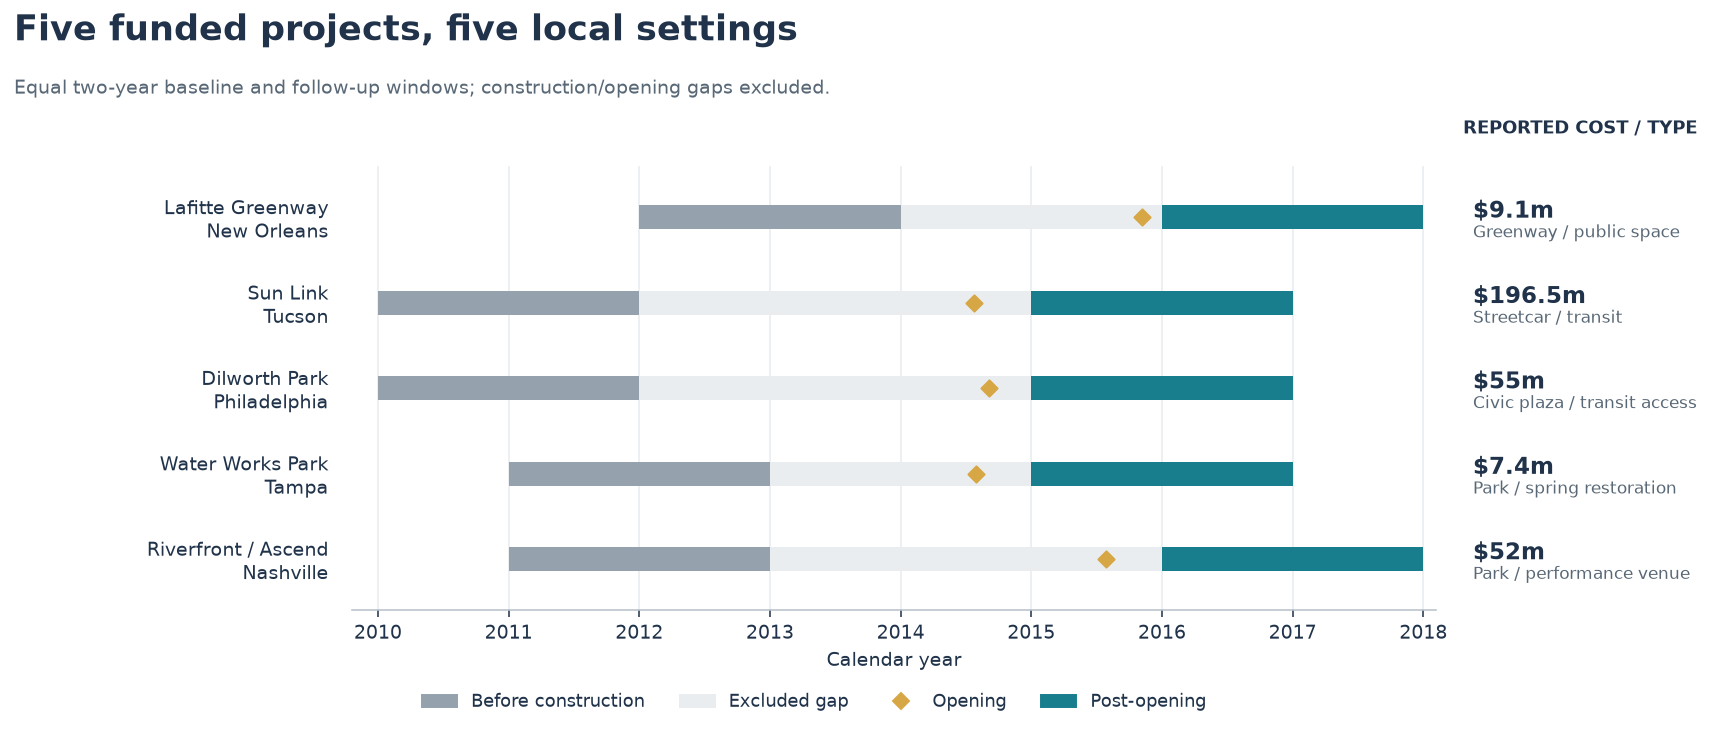

In [2]:
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from types import SimpleNamespace
viz=SimpleNamespace(ORDER=ORDER,study_design=study_design,coverage=coverage,text_diagnostics=text_diagnostics,
                    outcome_panel=outcome_panel,income_panel=income_panel,sensitivity=sensitivity,
                    topic_panel=topic_panel,sun_panel=sun_panel)

BASE=Path.cwd(); DATA=BASE/'study_data'; FIGURES=BASE/'figures'
# If only the assignment notebook is supplied, restore its embedded aggregate inputs.
# These are the same audited tables, not synthetic data or individual reviews.
if not DATA.exists():
    embedded=json.loads((BASE/'ProjectEDA_Team4.ipynb').read_text())['metadata']['aggregate_inputs']
    DATA.mkdir()
    for filename,content in embedded.items():
        assert Path(filename).name==filename
        (DATA/filename).write_text(content)
read=lambda name: pd.read_csv(DATA/name)
registry=pd.DataFrame(json.loads((DATA/'project_registry.json').read_text()))
activity=read('engagement.csv'); experience=read('experience.csv')
support=read('support.csv'); quality=read('quality.csv')
text_overview=read('text_overview.csv'); influence=read('influence.csv')
# Verify the compact aggregate inputs against the recorded manifest.
provenance=json.loads((DATA/'provenance.json').read_text())
assert all(hashlib.sha256((DATA/f).read_bytes()).hexdigest()==h
           for f,h in provenance['files'].items())
assert set(registry.project)==set(viz.ORDER)
def table(df, caption=None):
    if caption: display(HTML('<p class="table-caption">'+caption+'</p>'))
    display(HTML(df.to_html(index=False, border=0, na_rep='—', classes='eda-table')))
def figure(fig):
    plt.show(); plt.close(fig)
figure(viz.study_design(registry, FIGURES))


**Figure 1.** Each case compares two full baseline years with two full post-opening years. Gaps are excluded to avoid mixing construction and operation. The opening marker does not imply an immediate effect.

**Shared comparison:** nearby means within **500 m** of the project footprint; controls are same-city businesses **more than 1.5 km and up to 8 km** away. Sensitivities use 250 m and 1,000 m. A baseline business needs at least five reviews and complete matching covariates. It is matched, with replacement, to a business in the same coarse category and baseline ZIP-income band, using standardized log baseline reviews, baseline VADER, log ZIP income and poverty rate. No post-period activity is used for matching. Post-period zeros remain in the engagement analysis.

This is a descriptive matched comparison, not an experiment. We also show an inclusive **all-business Sun Link corridor analysis** in Section 5.5; that answers a different question about area activity and changing business composition.


## 3. Data description and summary statistics
The five original geographic extracts contain **2,004,265 review records**, including **704,025** in the chosen pre/post windows. The text diagnostics below use all **97,896 nearby pre/post reviews**. The full Sun Link audit adds seven nearby listings excluded by the original ZIP/city filters, giving 717 listings for its inclusive case study.

| Unit / fields | Type | Meaning |
|---|---|---|
| Business, review and reviewer IDs | String | Link records and de-duplicate; not independent neighborhood observations |
| Date, year and period | Date / categorical | Review/event timing and pre/post assignment |
| Latitude, longitude, distance | Numeric | Current coordinate proximity to the mapped footprint |
| Review text, embedding category | Text / categorical | Language and exploratory discussion category |
| Stars; VADER compound | Ordinal 1–5; numeric −1 to +1 | Whole-review rating and lexicon sentiment |
| Review, reviewer, check-in, tip counts | Nonnegative counts | Recorded activity; different proxies with different coverage |
| ZIP income, poverty and income band | Numeric / categorical | Baseline neighborhood context, not individual reviewer income |
| Reported project cost and type | Numeric / categorical | Case attributes; costs are nominal and scope-dependent |


Project,Businesses ≤8km,Extracted reviews,Pre/post reviews ≤8km,Listings ≤500m,Pre/post reviews ≤500m,Median words,90th percentile words
Lafitte,5827,536263,209125,436,12400,79.0,235.0
Sun Link,5275,205489,64001,710,14722,83.0,235.0
Dilworth Park,10804,743862,250972,1697,53824,91.0,249.0
Water Works Park,4453,219523,74666,75,1233,90.0,246.0
Riverfront / Ascend,4817,299128,105261,308,15717,70.0,207.0


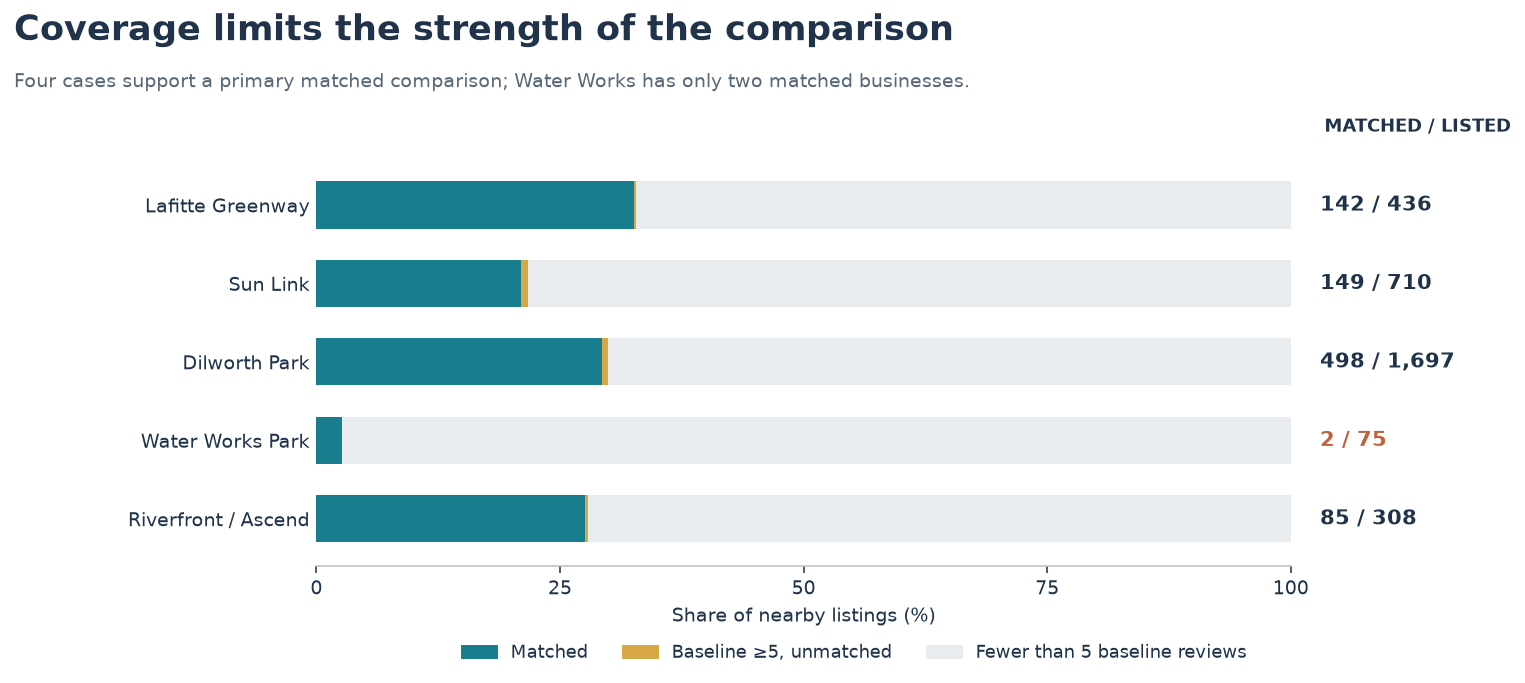

In [3]:
assert int(quality.reviews_extracted.sum())==2_004_265
assert int(quality.reviews_prepost.sum())==704_025
assert int(text_overview.reviews_500m.sum())==97_896
summary=quality[['project','businesses_8km','reviews_extracted','reviews_prepost']].merge(
    text_overview[['project','listed_500m','reviews_500m','median_words','p90_words']],on='project')
summary.columns=['Project','Businesses ≤8km','Extracted reviews','Pre/post reviews ≤8km',
                 'Listings ≤500m','Pre/post reviews ≤500m','Median words','90th percentile words']
table(summary.round(0))
figure(viz.coverage(text_overview, quality, support, FIGURES))


**Figure 2.** Sample size is constrained by baseline activity and comparison support, not by the total number of reviews. Water Works has 75 nearby listings but only two matched baseline businesses. It remains one of the five cases; its primary estimate is suppressed. At 1,000 m it has 23 pairs, all in the higher local-income band.

### Text quality and VADER validation
We score **raw text** with VADER, keeping negation and punctuation. Negative compound is ≤−0.05, positive is ≥+0.05, and intermediate scores are neutral. Stop words are removed only for embeddings/descriptive terms. Stars are an imperfect external check, not human annotation. Following Cameron's review, we compare VADER with a majority-class baseline and inspect negative-class errors rather than reporting accuracy alone. [VADER method and implementation](https://github.com/cjhutto/vaderSentiment)


Diagnostic,Value
Reviews with 1–2 or 4–5 stars,"85,320"
Always-positive accuracy,79.7%
VADER accuracy (neutral counts as incorrect),86.7%
Negative-class recall,43.8%
Low-star reviews labeled positive,53.6%


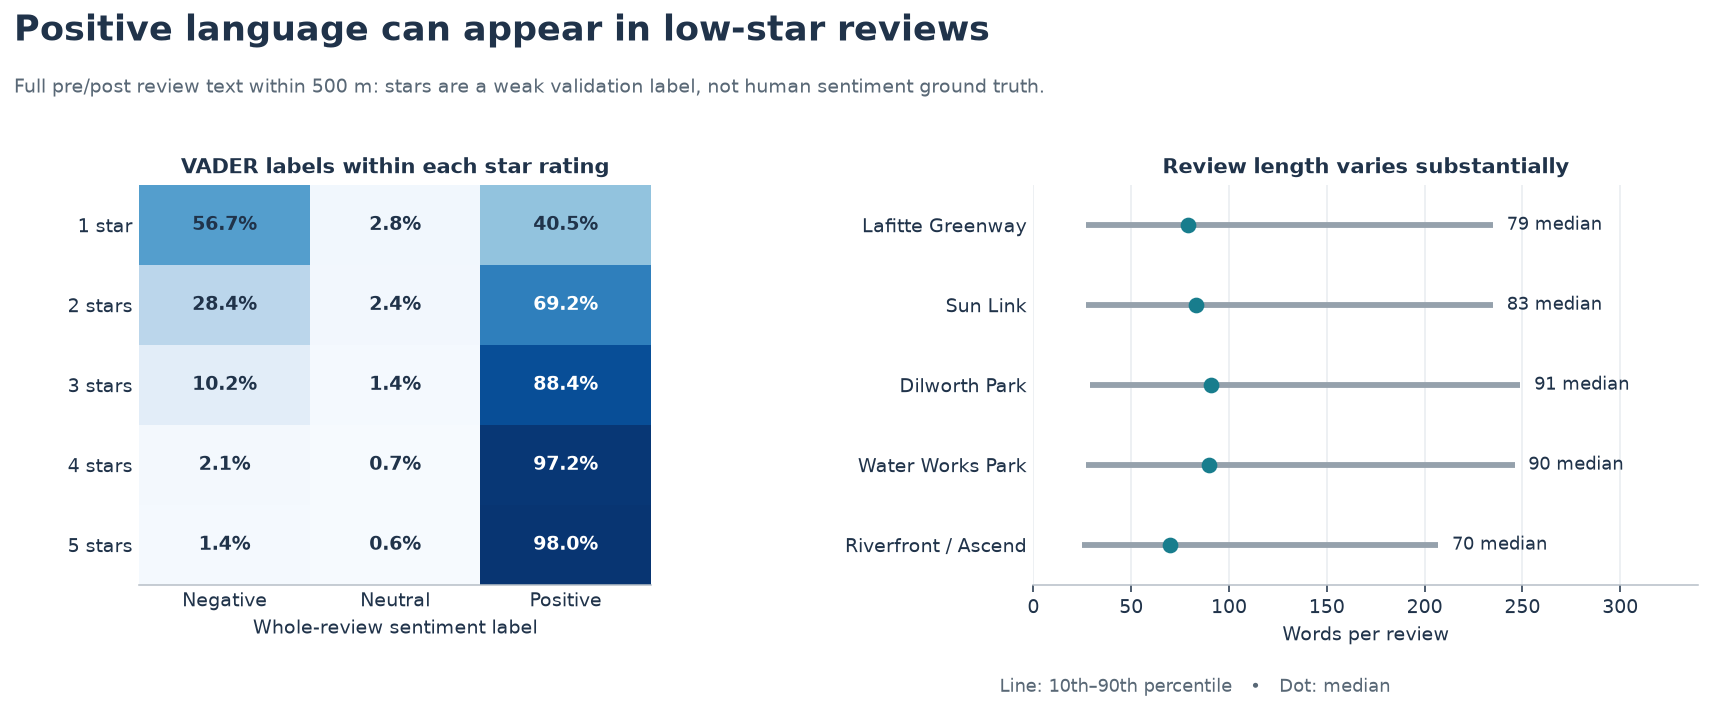

In [4]:
cm=read('vader_star_counts.csv')
binary=cm[cm.stars.ne(3)]  # Exclude three stars only for this weak-label check.
total=binary.reviews.sum()
majority=binary[binary.stars.ge(4)].reviews.sum()/total
correct=binary[(binary.stars.ge(4)&binary.vader_label.eq('Positive')) |
               (binary.stars.le(2)&binary.vader_label.eq('Negative'))].reviews.sum()/total
low=binary[binary.stars.le(2)]
negative_recall=low[low.vader_label.eq('Negative')].reviews.sum()/low.reviews.sum()
false_positive=low[low.vader_label.eq('Positive')].reviews.sum()/low.reviews.sum()
table(pd.DataFrame({'Diagnostic':['Reviews with 1–2 or 4–5 stars','Always-positive accuracy',
                                 'VADER accuracy (neutral counts as incorrect)',
                                 'Negative-class recall','Low-star reviews labeled positive'],
                    'Value':[f'{total:,}',f'{majority:.1%}',f'{correct:.1%}',
                             f'{negative_recall:.1%}',f'{false_positive:.1%}']}))
figure(viz.text_diagnostics(cm, text_overview, FIGURES))


**Figure 3.** VADER reaches 86.7% accuracy versus a 79.7% always-positive baseline, but identifies only 43.8% of low-star reviews as negative; 53.6% are labeled positive. Positive words within a complaint and mixed experiences are plausible contributors. These figures diagnose disagreement with star labels; they do not establish VADER's accuracy against human sentiment. Median review length ranges from 70 to 91 words, with long upper tails, making length-stratified validation appropriate.

## 4. Data quality and suitability
The data are suitable for **exploratory comparisons of recorded engagement and expressed business experience**. They are insufficient for proving community improvement or a spending threshold.

| Issue | Consequence and response |
|---|---|
| Uneven sample support | Display pair/control counts; suppress main or income estimates with fewer than 20 pairs. This display rule is not a power calculation. |
| Missing economic context | Matched analysis excludes incomplete covariates; inclusive Sun Link retains an Unknown group. Missingness is reported below. |
| Current geometry and postal ZIPs | ZIPs are not Census ZCTAs, and neither is a walking catchment. Coordinates and boundaries are historical proxies. Rivers/highways and spillovers can invalidate Euclidean proximity. |
| Non-comparable project footprints | Lafitte maps 3.70 km versus 4.18 km advertised. Water Works maps 3.67 acres versus roughly 5 project acres. Nashville uses the southern Ascend component, 12.53 current acres versus an 11-acre addition, excluding the older northern park. Historical scope needs verification. |
| Selection and composition | Yelp users/listings are self-selected. More reviews or first observed reviews cannot verify visits, residency, business births, survival or profit. Photos are absent from this archive. |
| Residual confounding | Other redevelopment, tourism, business mix and platform adoption may drive changes. Matching addresses only recorded baseline covariates. |
| Repeated observations | Controls are reused and ZIP context is shared; pairs and reviews are not independent. No naive significance tests or independent-pair confidence intervals are reported. |
| Cost and denominator uncertainty | Public outlay and historical catchment population are not reconciled. No project spending-per-resident or income-specific budget allocation is calculated. |


In [5]:
missing=read('missingness.csv')
context=quality[['project','missing_income_businesses','businesses_8km']].copy()
context['Missing income (%)']=100*context.missing_income_businesses/context.businesses_8km
table(context.rename(columns={'project':'Project','missing_income_businesses':'Missing ZIP income',
                              'businesses_8km':'Businesses ≤8km'}).round(2))
field_missing=missing.groupby(['unit','field'],as_index=False)[['records','missing']].sum()
field_missing['Missing (%)']=100*field_missing.missing/field_missing.records
table(field_missing.round(2), 'Missingness after geographic/date selection; zero coordinate missingness reflects filtering.')
cohort=support.query("radius_m==500 and income_group=='All'")[['project','eligible_near','matched_pairs','distinct_controls']]
table(cohort.rename(columns={'project':'Project','eligible_near':'Eligible nearby',
                            'matched_pairs':'Matched businesses','distinct_controls':'Distinct controls'}))


Project,Missing ZIP income,Businesses ≤8km,Missing income (%)
Lafitte,74,5827,1.27
Sun Link,45,5275,0.85
Dilworth Park,148,10804,1.37
Water Works Park,44,4453,0.99
Riverfront / Ascend,75,4817,1.56


unit,field,records,missing,Missing (%)
Businesses within8km,categories,31176,15,0.05
Businesses within8km,latitude,31176,0,0.00
Businesses within8km,longitude,31176,0,0.00
Businesses within8km,postal_code,31176,15,0.05
Near pre/post reviews,compound,97896,0,0.00
Near pre/post reviews,stars,97896,0,0.00
Near pre/post reviews,word_count,97896,0,0.00


Project,Eligible nearby,Matched businesses,Distinct controls
Lafitte,142,142,80
Sun Link,151,149,86
Dilworth Park,498,498,272
Water Works Park,2,2,2
Riverfront / Ascend,85,85,69


## 5. Preliminary exploration
### 5.1 Engagement and customer experience
For activity, compute the near and matched growth factors from mean counts: post / baseline. **Relative growth = 100 × [(near growth factor / matched growth factor) − 1].** A positive value means faster growth nearby; it is not a percentage-point difference or a causal effect. Unique reviewers are counted per business-period and can repeat across businesses.

Stars and VADER use **near mean change minus matched mean change**. They require at least five reviews in both periods for both pair members, producing a smaller, post-selected experience cohort. A business with no post reviews contributes zero activity but has no defined post sentiment. These are different populations and outcomes.


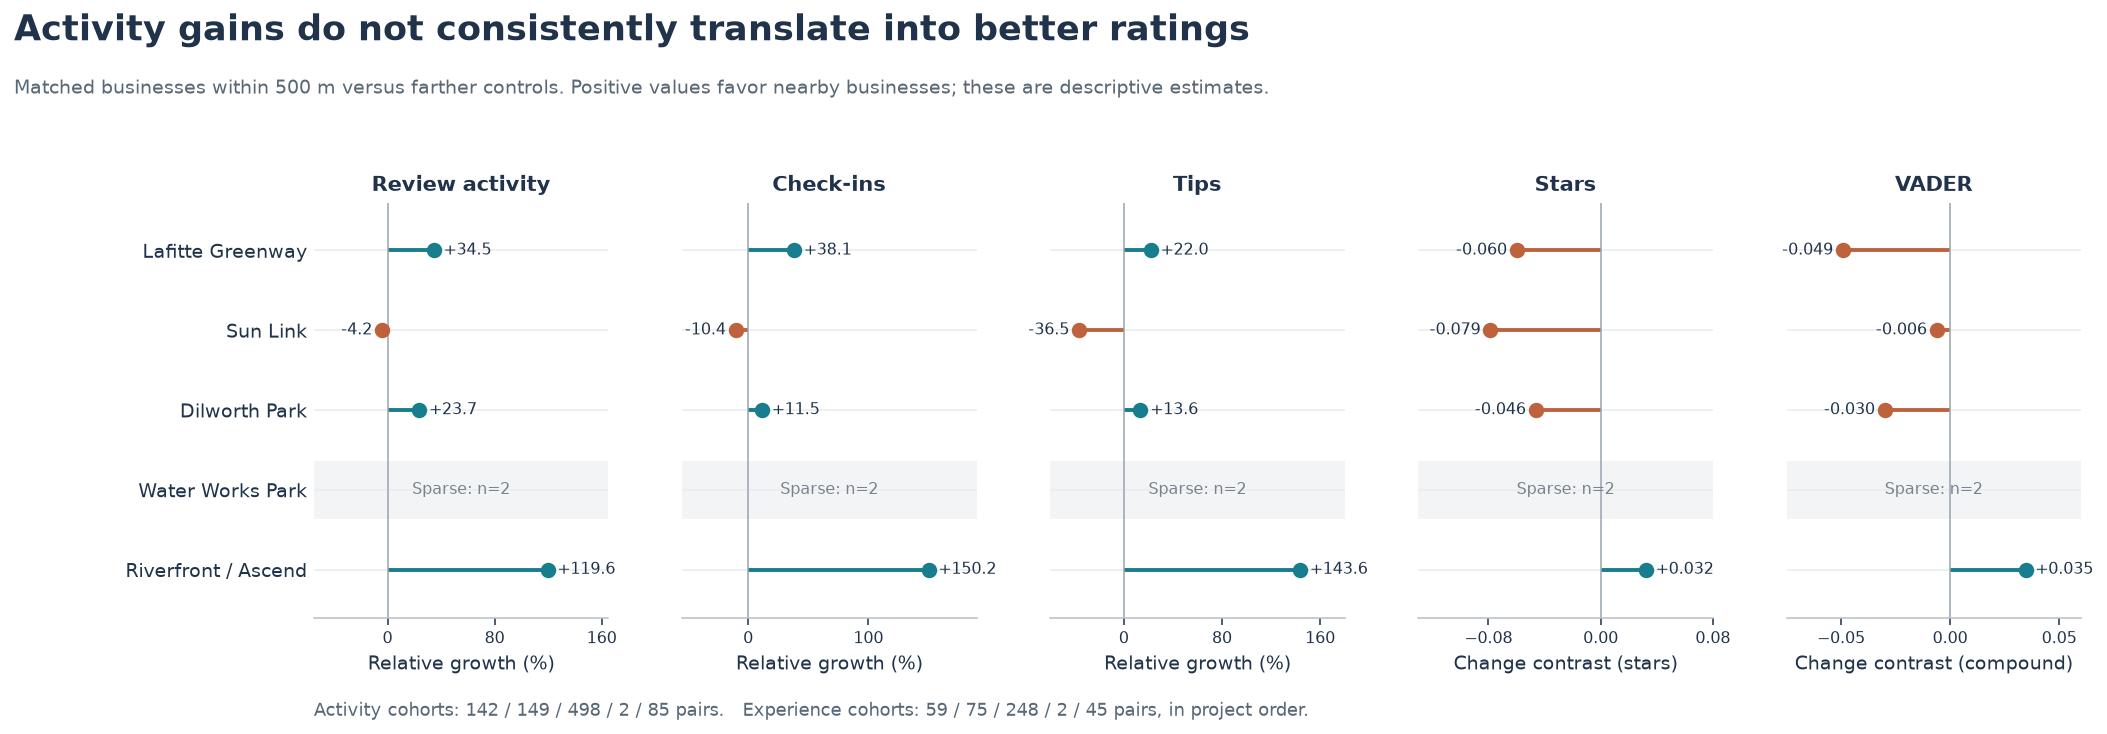

In [6]:
# Recompute the main contrasts from saved mean/count summaries; verify stored results.
valid=(activity.near_pre>0)&(activity.control_pre>0)&(activity.control_post>0)
recomputed=100*((activity.near_post/activity.near_pre)/(activity.control_post/activity.control_pre)-1)
assert np.allclose(recomputed[valid],activity.loc[valid,'relative_growth_pct'],equal_nan=True)
activity['relative_growth_pct']=recomputed.where(valid)
assert np.allclose(experience.near_change-experience.control_change,experience.contrast,equal_nan=True)
experience['contrast']=experience.near_change-experience.control_change
figure(viz.outcome_panel(activity, experience, FIGURES))


**Figure 4.** Lafitte and Riverfront/Ascend have positive engagement contrasts across reviews, check-ins and tips. Sun Link's matched activity contrasts are negative. Dilworth's aggregate engagement is positive, but it is sensitive to weighting and distance (Section 5.3). Whole-review stars and VADER do not show consistent improvement: only Nashville has positive primary contrasts for both, and those changes are small. H1 receives mixed, project-specific support; H2 is not consistently supported.

**Cost/type comparison:** the highest-cost case, Sun Link, does not show the largest engagement contrast. Several public-space cases are positive, but one project per city and largely distinct types cannot isolate spending amount or project type from context. The cost labels in Figure 1 are descriptive; fitting a five-point cost regression would not resolve this identification problem.

### 5.2 Differences by baseline local income
Income bands are terciles of **distinct study ZIPs**, fixed using baseline ACS values. They are relative within each city's study area, not national income classes, equal population groups or the incomes of people writing reviews. Matching occurs within the same income band and category.


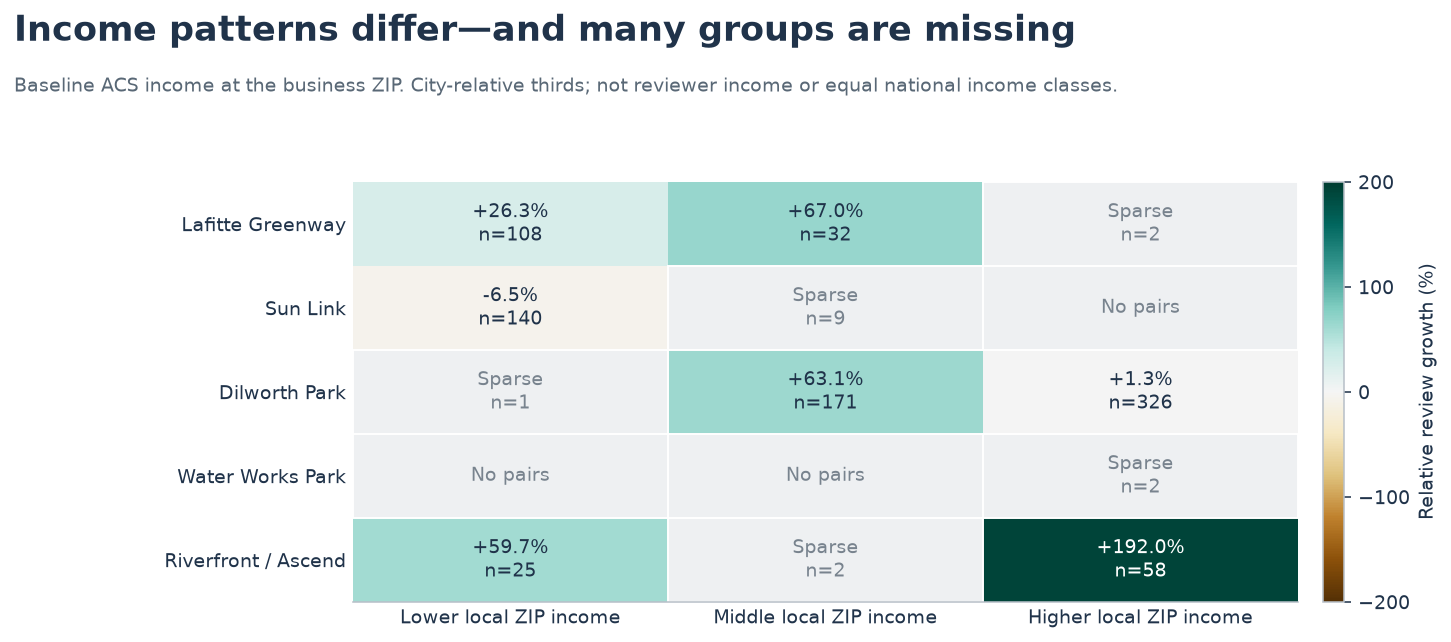

Project,Band,ACS end year,Lower income edge ($),Upper income edge ($),ZIPs
Lafitte,Lower,2012,17300.0,31735.0,6
Lafitte,Middle,2012,31735.0,41456.0,6
Lafitte,Higher,2012,41456.0,71944.0,6
Sun Link,Lower,2011,25350.0,42423.0,10
Sun Link,Middle,2011,42423.0,55904.0,9
Sun Link,Higher,2011,55904.0,83314.0,9
Dilworth Park,Lower,2011,14586.0,31557.0,13
Dilworth Park,Middle,2011,31557.0,45619.0,12
Dilworth Park,Higher,2011,45619.0,93222.0,12
Water Works Park,Lower,2012,26537.0,34317.0,9


In [7]:
figure(viz.income_panel(activity, support, FIGURES))
bands=read('income_bands.csv')
table(bands.rename(columns={'project':'Project','income_group':'Band','acs_year':'ACS end year',
                            'lower_edge':'Lower income edge ($)','upper_edge':'Upper income edge ($)'}).round(0),
      'Fixed local ZIP-income boundaries; ACS five-year estimates have sampling uncertainty.')


**Figure 5.** Lower-income ZIPs show positive relative review growth near Lafitte (+26.3%) and Nashville (+59.7%), but negative growth near Sun Link (−6.5%). Dilworth has only one lower-band pair; its supported middle band is stronger than its higher band. Many groups are absent or sparse. These patterns do not establish that one income group benefits more, and they cannot support spending per resident by income group.

### 5.3 Robustness: proximity, concentration and prior trends


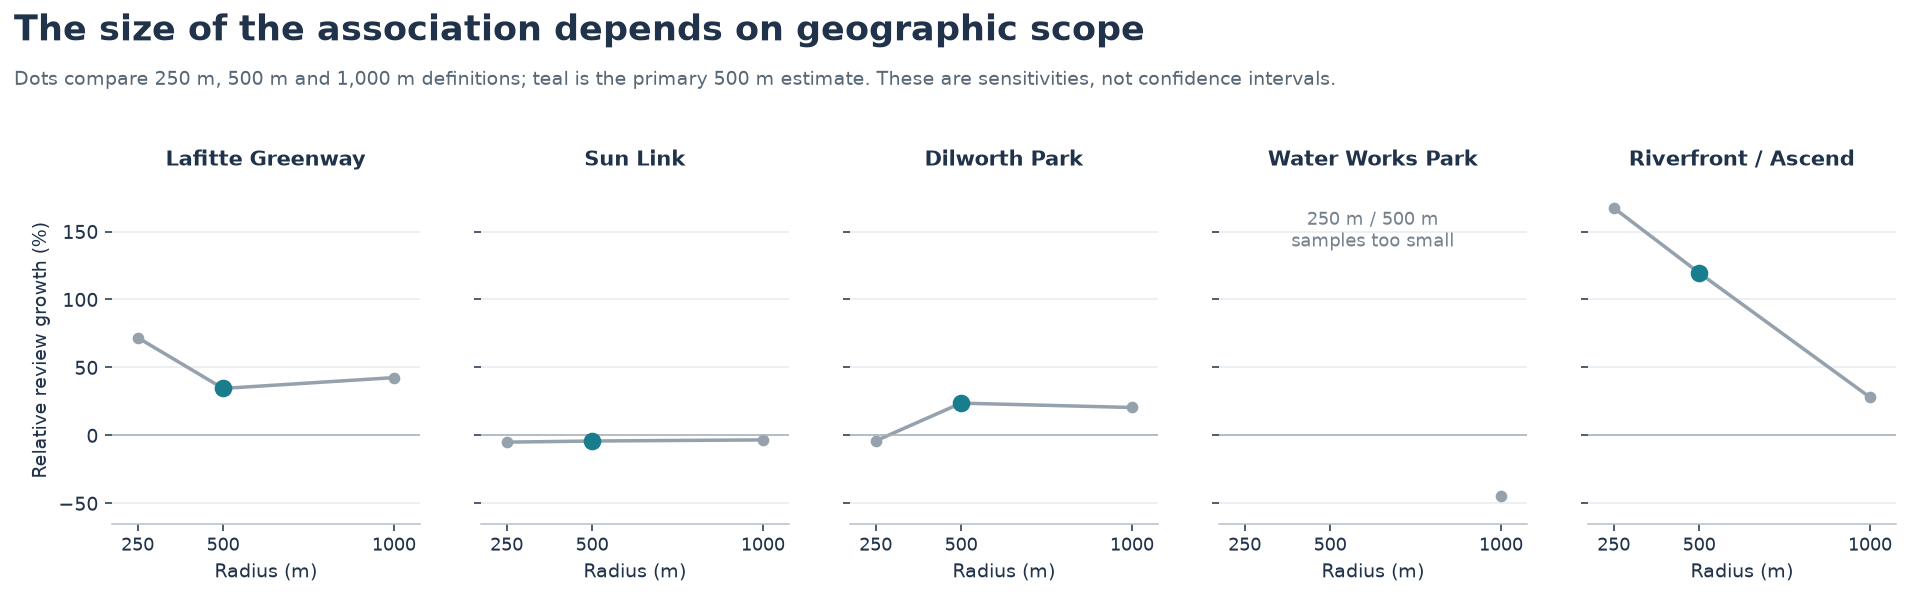

check,project,Full cohort,Match distance <=1,Remove top5% baseline review counts
,Lafitte,34.5,25.6,20.7
,Sun Link,-4.2,-3.3,-15.1
,Dilworth Park,23.7,24.3,5.8
,Water Works Park,—,—,—
,Riverfront / Ascend,119.6,118.9,117.4


project,pairs,relative_growth_pct,log1p_contrast
Lafitte,142,34.535,0.324
Sun Link,149,-4.177,-0.290
Dilworth Park,498,23.702,-0.112
Water Works Park,2,—,—
Riverfront / Ascend,85,119.593,0.519


In [8]:
figure(viz.sensitivity(activity, influence, FIGURES))
checks=influence.query("income_group=='All' and pairs>=20").pivot(
    index='project',columns='check',values='relative_growth_pct').reindex(viz.ORDER)
table(checks.reset_index().round(1), 'Relative review growth (%) after alternative baseline-only inclusion rules.')
weighting=activity.query("radius_m==500 and income_group=='All' and metric=='reviews' and window=='Main'")[
    ['project','pairs','relative_growth_pct','log1p_contrast']].copy()
weighting.loc[weighting.pairs<20,['relative_growth_pct','log1p_contrast']]=np.nan
table(weighting.round(3), 'Aggregate growth and mean paired change in log(1+reviews) weight businesses differently.')


**Figure 6.** Lafitte and Nashville remain positive across the three radii; Sun Link remains negative. Dilworth changes sign at 250 m, and its 500 m mean log(1+reviews) contrast is negative despite positive aggregate growth. Removing the busiest baseline 5% reduces Dilworth's aggregate contrast from +23.7% to +5.8%. Thus the gain is not broadly shared across businesses. Water Works’ 1,000 m sensitivity is −44.8% with 23 pairs; it does not rescue its sparse primary sample.

Covariate balance is imperfect: Lafitte's poverty gap is 0.356 control-pool standard deviations. Earlier-period aggregate review contrasts also differ—about +14.2% for Dilworth, for example. Because these diagnostic cohorts are selected using later baseline activity, the earlier comparisons are **not valid causal placebo tests** or proof of parallel trends. Current project differences may reflect downtown tourism, private investment or other public improvements. These checks make the uncertainty visible rather than prove an effect.

### 5.4 What reviewers discuss: embedding categories and sentiment
We retain a baseline-trained text pipeline: 100-dimensional Word2Vec, mean non-stopword sentence vectors, and six MiniBatchKMeans categories. The original Lafitte/Sun Link baseline model has a 6,966-word vocabulary. Its saved categories were reconstructed with 100% agreement, then frozen for the three new cities; no post-period text or new-city outcomes refit the model.

Up to 1,500 reviews are sampled per project × near/comparison area × pre/post period, with recorded seeds 509/510. Across five cases there are 28,233 sampled reviews; fractions differ, and Water Works has only 48 nearby baseline reviews. Sentences must have 4–150 alphabetic tokens and at least three in-vocabulary non-stopwords. VADER scores the raw sentence; sentiment is first averaged within review/category so verbose reviews do not receive extra weight within a category. A review can belong to several categories.


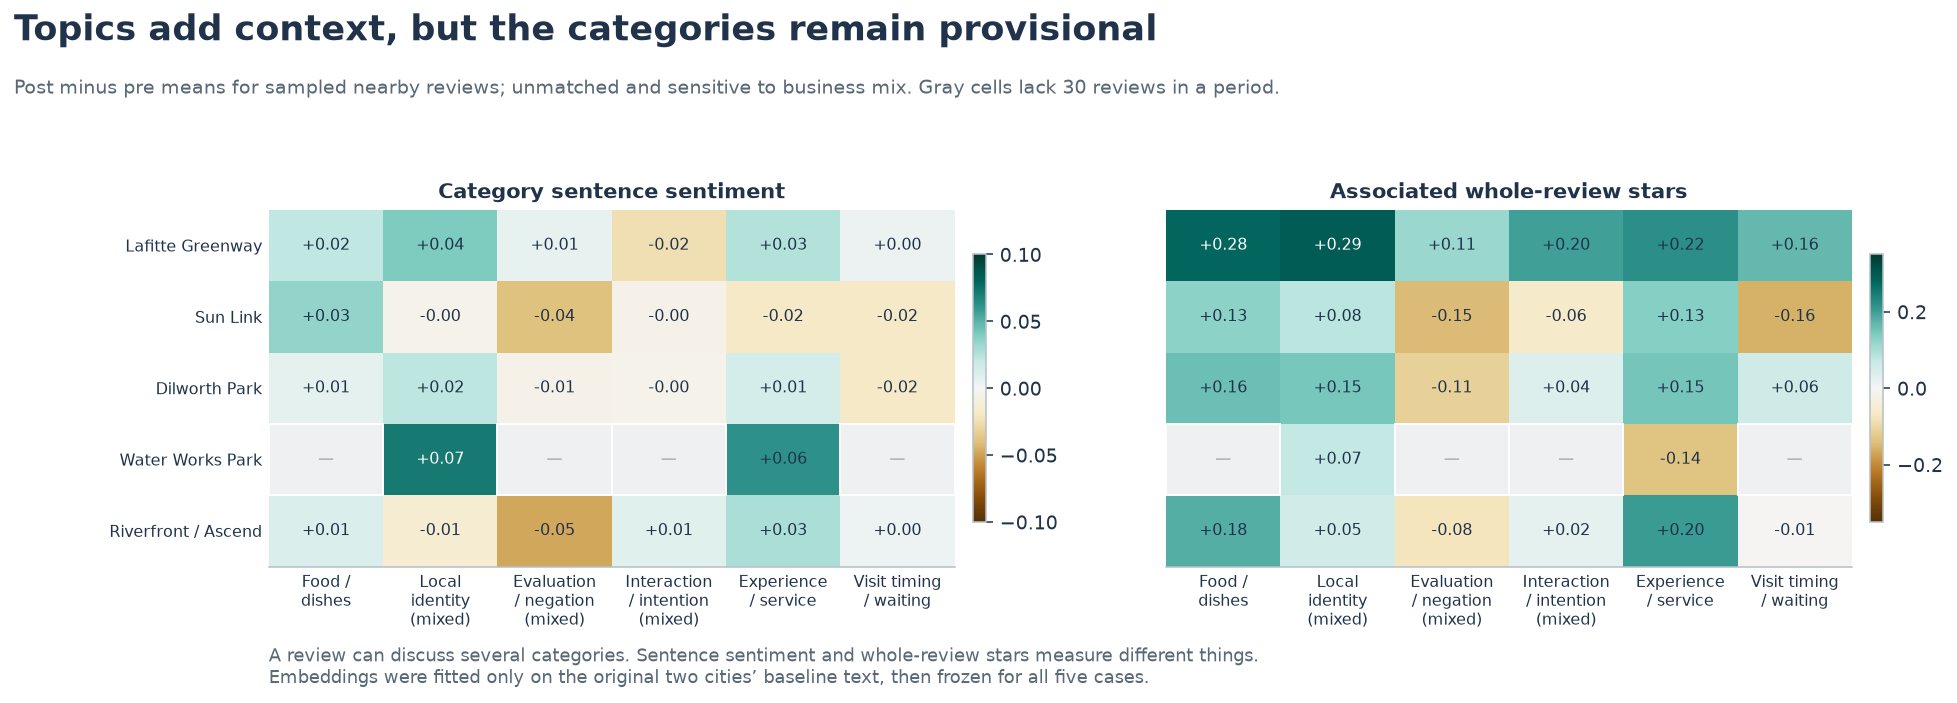

project,period,eligible_sentences,assigned_sentences,assignment_fraction,token_coverage
Dilworth Park,post,21708,19188,0.884,0.912
Dilworth Park,pre,26237,23038,0.878,0.898
Water Works Park,post,21658,18777,0.867,0.910
Water Works Park,pre,12421,10919,0.879,0.903
Riverfront / Ascend,post,20884,17963,0.860,0.916
Riverfront / Ascend,pre,25724,22551,0.877,0.903


project,period,income_group,category,sample_reviews,businesses,vader,stars,sparse
Dilworth Park,post,Higher,Food and dishes,440,154,0.322,3.805,False
Dilworth Park,post,Higher,Location/local identity (mixed),435,213,0.252,3.687,False
Dilworth Park,post,Higher,Mixed evaluations/negation,343,187,0.114,3.324,False
Dilworth Park,post,Higher,Mixed interactions/intentions,443,223,0.219,3.571,False
Dilworth Park,post,Higher,Overall experience/service,577,236,0.444,3.792,False
Dilworth Park,post,Higher,Visit timing/waiting,460,215,0.158,3.502,False
Dilworth Park,post,Lower,Food and dishes,3,2,—,—,True
Dilworth Park,post,Lower,Location/local identity (mixed),2,1,—,—,True
Dilworth Park,post,Lower,Mixed interactions/intentions,1,1,—,—,True
Dilworth Park,post,Lower,Overall experience/service,2,2,—,—,True


project,period,category,assigned_reviews,prevalence_pct
Dilworth Park,post,Location/local identity (mixed),1499,54.6
Dilworth Park,post,Food and dishes,1499,57.6
Dilworth Park,post,Mixed evaluations/negation,1499,41.9
Dilworth Park,post,Overall experience/service,1499,70.9
Dilworth Park,post,Mixed interactions/intentions,1499,54.2
Dilworth Park,post,Visit timing/waiting,1499,55.6
Dilworth Park,pre,Location/local identity (mixed),1494,61.6
Dilworth Park,pre,Food and dishes,1494,58.4
Dilworth Park,pre,Mixed evaluations/negation,1494,45.9
Dilworth Park,pre,Overall experience/service,1494,71.8


In [9]:
sampling=read('topic_sampling.csv');original=json.loads((DATA/'embedding_audit.json').read_text())
transfer=json.loads((DATA/'transfer_audit.json').read_text())
assert int(sampling.sample_reviews.sum())==28_233
assert transfer['baseline_reconstruction_agreement']==1.0
figure(viz.topic_panel(read('topics.csv'), FIGURES))
coverage=read('transfer_coverage.csv')
table(coverage[['project','period','eligible_sentences','assigned_sentences','assignment_fraction','token_coverage']].round(3),
      'Fixed-model transfer coverage in the three added cities.')
# Full category/income summaries remain accessible without overwhelming the report.
income_topics=read('income_topics.csv');near_topics=income_topics[income_topics.area.eq('near')]
display(HTML('<details><summary>Category sentiment and associated stars by baseline income</summary>'+
             near_topics.drop(columns=['area']).round(3).to_html(index=False,na_rep='—')+'</details>'))
prev=read('topic_prevalence.csv');display(HTML('<details><summary>Category prevalence in sampled nearby reviews</summary>'+
    prev[prev.area.eq('near')][['project','period','category','assigned_reviews','prevalence_pct']].round(1).to_html(index=False)+'</details>'))


**Figure 7.** Categories add context but do not reveal a uniform sentiment improvement. Several clusters mix evaluation, negation and interaction language rather than forming clean topics; labels remain provisional and require human review. Because sentiment-bearing words helped form clusters, category/sentiment associations are partly representation-dependent. New-city assignment coverage is about 86–88% of eligible sentences.

These are sampled, unmatched descriptions—not the matched investment contrasts. The stars panel uses whole-review ratings, not aspect-specific stars. Sparse means require at least 30 review/category observations in each displayed period. Category prevalence can sum above 100%, and sampled category counts cannot measure population engagement.

### 5.5 Sun Link: include all businesses along the full line
The original geometry already covered the complete route. The expanded analysis removes baseline-review, original ZIP-list, city-label, category, open-status and Census-completeness filters for an inclusive view of **717 Yelp listings within 500 m**, from Mercado through downtown to the university. Seven extra records have missing/inconsistent city or ZIP metadata; they remain flagged, with an exclusion sensitivity. These listings are not a complete census of operating businesses. [Official route map](https://www.suntran.com/wp-content/uploads/2021/07/Sun-Link-route-Map.pdf)


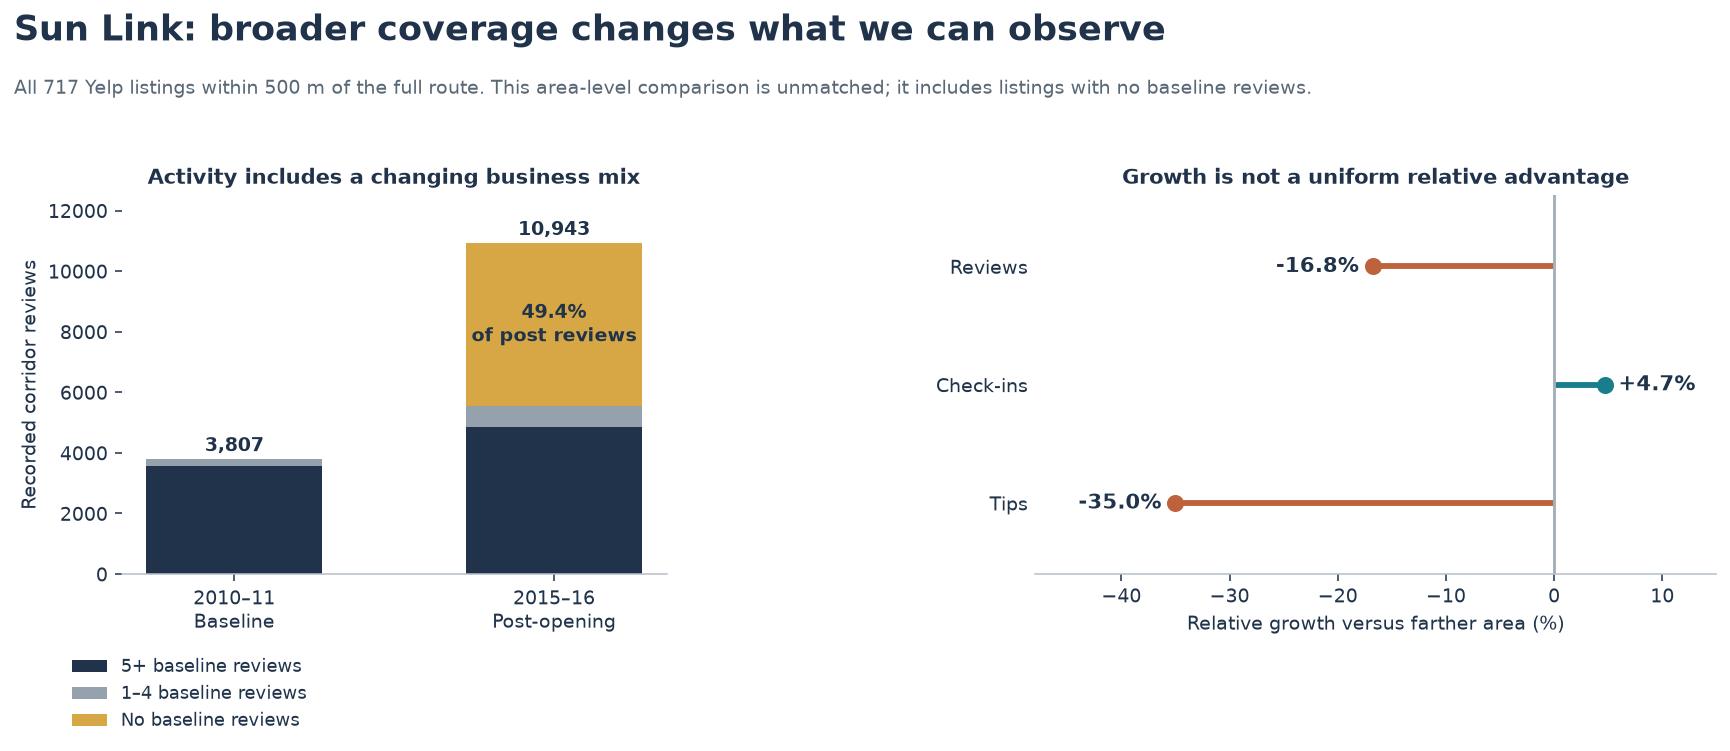

listed_businesses,baseline_reviewed,post_reviewed,no_baseline_reviews,unknown_income,location_flags
717,278,470,439,34,7


Measure,Corridor before,Corridor after,Corridor change,Farther change,Change contrast
compound,0.7575,0.6963,-0.0612,-0.1064,0.0452
stars,3.7757,3.8634,0.0877,-0.0160,0.1037


In [10]:
sun_scopes=read('sun_scopes.csv');sun_composition=read('sun_composition.csv')
figure(viz.sun_panel(sun_composition, sun_scopes, FIGURES))
sun_cov=read('sun_coverage.csv').query('radius_m==500')
table(sun_cov[['listed_businesses','baseline_reviewed','post_reviewed','no_baseline_reviews','unknown_income','location_flags']],
      'Inclusive 500 m corridor coverage; baseline 2010–11 versus post 2015–16.')
sun_exp=read('sun_experience.csv').query('radius_m==500').pivot(index='metric',columns=['area','period'],values='mean')
sun_exp['Near change']=sun_exp[('Near','post')]-sun_exp[('Near','pre')]
sun_exp['Farther change']=sun_exp[('Comparison','post')]-sun_exp[('Comparison','pre')]
sun_exp['Change contrast']=sun_exp['Near change']-sun_exp['Farther change']
sun_table=pd.DataFrame({'Measure':sun_exp.index,'Corridor before':sun_exp[('Near','pre')].values,'Corridor after':sun_exp[('Near','post')].values,'Corridor change':sun_exp['Near change'].values,'Farther change':sun_exp['Farther change'].values,'Change contrast':sun_exp['Change contrast'].values})
table(sun_table.round(4))
display(HTML('<details><summary>Inclusive Sun Link income and all-review topic results</summary>'+
    read('sun_income_support.csv').to_html(index=False)+'<p>Unpaired review-growth comparisons by income</p>'+
    read('sun_income.csv').query("dimension=='income_group' and metric=='reviews'").round(3).to_html(index=False,na_rep='—')+
    '<p>Frozen categories applied to every qualifying pre/post corridor review</p>'+
    read('sun_topics.csv').round(3).to_html(index=False,na_rep='—')+'</details>'))


**Figure 8.** Corridor reviews rise from 3,807 to 10,943 (+187.4%) and reviewed businesses from 278 to 470. Nearly half of post reviews come from businesses with no baseline reviews; those are not necessarily new businesses. Farther-area reviews grow 245.4%, leaving a −16.8% relative corridor contrast, while check-ins have a small +4.7% advantage. Excluding flagged locations yields essentially the same review result (−16.7%).

Pooled corridor stars rise slightly (3.776→3.863), while VADER falls (0.758→0.696). Farther-area declines are larger, producing positive **relative pooled** experience contrasts. Business/reviewer composition changes, so this does not overturn the matched result or demonstrate within-business improvement. The full topic extension processes all 14,750 pre/post corridor reviews, assigning 98,723 qualifying sentences with the same frozen model; it is retained in the detail table above.

## 6. Interpretation and proposed AI solution
The evidence supports **project-specific exploratory engagement associations**, especially near Lafitte and Nashville. It does not support a general claim that spending improves review sentiment, identify a spending threshold, or establish an equitable benefit across income groups. H3 remains an exploratory comparison with substantial missing support. Increased activity and better customer experience should remain separate outcomes.

Our next-stage solution is an **auditable project-comparison tool**, not a causal-effect score. Course techniques—pandas aggregation, text preprocessing, VADER, embeddings, clustering and visual comparison—provide the initial workflow. The next stage should prioritize measurement and validation:

| Component | Planned method and evaluation |
|---|---|
| Review sentiment | Human-label a sample stratified by project, time, stars and length. Compare VADER with TF-IDF + a linear classifier and, if justified, a pretrained language model. Report macro F1 and negative recall on business/time-held-out data. |
| Review categories | Human-audit coherent and mixed clusters; measure agreement and category precision/recall. Compare the frozen embedding approach with a simple supervised text baseline. Do not optimize labels to obtain positive project findings. |
| Investment exposure | Verify historical footprints, dates, actual public expenditures and pre-project small-area population. Allocate residents to a defensible catchment before calculating spending per resident. |
| Association design | Collect more projects within each type, define outcomes and lags before testing, inspect pre-trends and use uncertainty methods accounting for shared controls, ZIPs and projects. Five heterogeneous cases are insufficient for cost/type causal inference. |
| Decision interface | Show activity and experience separately, with coverage, income context, source provenance and sparse-result warnings. Display uncertainty rather than label a project successful from review growth alone. |

The earlier broad federal-assistance/ZIP exploration is retained in the project history. Cameron's robustness review motivated greater attention to within-place comparisons, exposure quality and the majority-class sentiment baseline. The submission focuses on documented projects because a federal transaction's recorded ZIP is not its neighborhood benefit footprint.

## 7. Reproduction and scope of this deliverable
Run this notebook from its folder with Python 3.11/3.12, `pandas`, `numpy`, `matplotlib`, `nbformat`, `nbclient`, `nbconvert` and `ipykernel`. The notebook embeds its compact aggregate inputs and all figure code. If `study_data/` is absent, the first analysis cell restores those tables from notebook metadata. A separate `eda_visuals.py` mirrors the figure code for maintenance; it is not required to run this notebook. Each run redraws and saves PNG/SVG figures. The notebook verifies input hashes, recomputes contrasts and diagnostics, and displays all results. The HTML is self-contained for reading; the notebook can reproduce the displayed analysis from its embedded aggregates using the listed Python dependencies.

Raw extraction, VADER scoring, matching and embedding training are preparation stages, not rerun in every notebook execution. Their reproducible local scripts and original audits remain in `Five Project Study`, `Sun Link Full Corridor`, the two pilot folders and `Embedding Categories`. `study_data/provenance.json` records the preparation sources and hashes. No raw review text or reviewer IDs are embedded in the submitted files or aggregate package. Supplementary notes describe the preparation and retained earlier analyses. No submission or teammate approval is implied.

## 8. Generative AI use
OpenAI Codex assisted with source audits, Census linkage, project selection support, Python implementation/debugging, embeddings, matching, diagnostics, figure design, notebook execution and drafting. Anthropic's Claude assisted Cameron's earlier rubric, sentiment-baseline and robustness review; those contributions informed this focused version. Category labels are provisional AI-assisted labels, not human-validated ground truth. All numerical findings shown here are computed from local data or verified aggregate outputs. The team remains responsible for understanding, verifying and explaining the code, sources, methods and conclusions.
